### Code funzionante

In [492]:
import math
import numpy as np
import matplotlib.pyplot as plt
from random import randrange
import random

In [526]:
bits = 128

In [575]:
a = random.getrandbits(bits)
b = 412332312

LUT_BITS = 8
LUT_SIZE = 1 << LUT_BITS

lut = [
    (1 << (bits * 2)) //
    ((1 << (bits - 1)) + (i << (bits - 1 - LUT_BITS)))
    for i in range(LUT_SIZE)
]

s = bits - b.bit_length()
b_norm = b << s

idx = (b_norm >> (bits - 1 - LUT_BITS)) & (LUT_SIZE - 1)

x = lut[idx]

for _ in range(4):
    x = (x * ((1 << (bits * 2 + 1)) - b_norm * x)) >> (bits * 2)

result = (a * x) >> ((bits * 2) - s)

print("A:", a)
print("B:", b)
print("My res:", result)
print("Expect:", a // b)

A: 321496060899178472425175264075599276402
B: 412332312
My res: 779701351416714759975384281975
Expect: 779701351416714759975384281975


### Todo: map the LUT as a polynomial

In [576]:
def get_bit(n, i):
    return (n >> i) & 1

In [577]:
def polylut(bit = 0):
    N = LUT_SIZE
    seq = np.array([get_bit(lut[i], bit) for i in range(N)], dtype=float)
    c = np.fft.fft(seq)  

    def f(x):
        s = 0.0
        for k in range(N):
            ang = 2 * math.pi * k * x / N
            s += c[k].real * math.cos(ang) - c[k].imag * math.sin(ang)
        return s / N

    return f

In [578]:
class Chebyshev:
    """
    Chebyshev(a, b, n, func)
    Given a function func, lower and upper limits of the interval [a,b],
    and maximum degree n, this class computes a Chebyshev approximation
    of the function.
    Method eval(x) yields the approximated function value.
    """
    def __init__(self, a, b, n, func):
        n = n + 1
        self.a = a
        self.b = b
        self.func = func

        bma = 0.5 * (b - a)
        bpa = 0.5 * (b + a)
        f = [func(math.cos(math.pi * (k + 0.5) / n) * bma + bpa) for k in range(n)]
        self.roots = f

        self.x = [math.cos(math.pi * (k + 0.5) / n) * bma + bpa for k in range(n)]

        fac = 2.0 / n
        self.c = [fac * sum([f[k] * math.cos(math.pi * j * (k + 0.5) / n)
                  for k in range(n)]) for j in range(n)]

    def eval(self, x):
        a,b = self.a, self.b
        #assert(a <= x <= b)
        y = (2.0 * x - a - b) * (1.0 / (b - a))
        y2 = 2.0 * y
        (d, dd) = (self.c[-1], 0)             # Special case first step for efficiency
        for cj in self.c[-2:0:-1]:            # Clenshaw's recurrence
            (d, dd) = (y2 * d - dd + cj, d)
        return y * d - dd + 0.5 * self.c[0]   # Last step is different

In [579]:
polyluts = []

for bit in range(bits + 2):
    f = polylut(bit)
    
    c = Chebyshev(0, LUT_SIZE, 851, f)
    
    polyluts.append(c)

1.776465010511208e-08

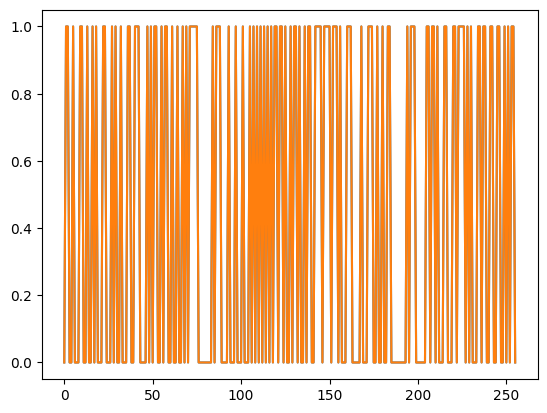

In [580]:
f = polylut(0)

c = Chebyshev(0, LUT_SIZE, 851, f)

x = np.arange(0, LUT_SIZE, 1)

y = np.vectorize(c.eval)(x)
plt.plot(x, y)

y_real = np.vectorize(f)(x)
plt.plot(x, y_real)


max(abs(y - y_real))

---

### Making the LUT polynomial

In [581]:
s = bits - b.bit_length()
b_norm = b << s

idx = (b_norm >> (bits - 1 - LUT_BITS)) & (LUT_SIZE - 1)

idx

137

In [582]:
binx = []

for i in range(bits * 2):
    if i >= len(polyluts):
        binx.append(0)
    else:
        binx.append(polyluts[i].eval(idx))

In [583]:
polydec = ([round(x) for x in list(binx)][::-1])

In [584]:
n = int("".join(map(str, polydec)), 2)

# We check that the polynomial LUT and the actual LUT are equal
n == lut[idx]

True

In [586]:
x = n

for _ in range(4):
    term = b_norm * x                  # Mult
    term = 2 ** (bits * 2 + 1) - term  # Implementato come !term + 1, dove i bit più alti di 33 sono a 0
    
    x = x * term                       # Mult normale
    x = x >> bits * 2                  # Shift gratis

result = (a * x) >> (bits * 2 - s)

print(result)
print(a // b)

779701351416714759975384281975
779701351416714759975384281975
